# Курс "Практикум по математической статистике"

# 3 курс ФПМИ МФТИ, осень 2025
## Практическое задание 1. Моделирование, оценки, свойства и сравнение.
### Дедлайн --- 27 сентября, 16:00

Это обязательное домашнее задание нашего курса. Мы предлагаем выполнять задания прямо в этом ноутбуке. Пожалуйста, не стирайте условия задач.

Сдавать ноутбук нужно будет в LMS.

---

В этом и последующих заданиях вам потребуется выполнять генерацию случайных величин из некоторого распределения, моделирование оценок параметров и проверку их теоретических свойств на практике. Для этого вам понадобится библиотека scipy.stats. Мы настоятельно рекомендуем для генерации выборок использовать именно эту библиотеку.

Настоятельно рекомендуемая форма оформления домашних заданий — это Jupyter Notebook и его pdf-версия с:

* условием задачи,
* решением (если требуется некоторый теоретический вывод),
* описанием плана решения, который потом реализуется в коде,
* собственно кодом,
* построенными графиками (если это требуется) и **выводом**, который как правило должен заключаться в объяснении практических результатов с использованием теоретических фактов. ***Вывод требуется даже в том случае, если в условии об этом явно не сказано!***
* некоторыми другими вещами, если об этом будет указано в задании.

Оценка за каждую задачу складывается из правильного выполнения всех этих пунктов. Закрывая на них глаза, вы сознательно понижаете свою оценку.

Каждая задача оценивается в 10 баллов.



In [636]:
# Matplotlib needed to correctly display suptitles,
# as well as some other minor things.
# I thought I might as well ensure everything is up to date
%pip  install --upgrade  --break-system-packages matplotlib numpy scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [637]:
from __future__ import annotations
import typing
import abc
import dataclasses
import itertools

In [638]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import seaborn as sns

sns.set(style='darkgrid')
%matplotlib inline

In [639]:
np.random.seed(42)

**Гайд, как моделировать оценки**:

В разных задачах Вы будете видеть ключевое слово "смоделируйте".
Для моделирования оценки нужно:
- Сгенерировать много выборок (число можете подобрать сами, чтобы в итоге результат был репрезентативный, а ячейка считалась не дольше 5 минут)
- По каждой выборке посчитать оценку. **Указание:** считать надо не циклом, а векторными вычислениями. Вычисление циклом будет прощаться **только** если нет другого способа вычисления (исключительно редкий случай)
- Получить выборку оценок. По ней обычно бывает выгодно построить KDE, прикинуть распределение и возможно проверить его на QQ-plot, посчитать статистики распределения (дисперсию, например)

### Задача 1



В этой задаче мы будем моделировать поведение оценки медианой для распределения Лапласа с плотностью $\frac{1}{2}exp(-|x - \mu|)$.

В этой задаче Вам предстоит:
- Получить и визуализировать выборку оценок параметра $\mu$
- Построить эмпирическое приближение плотности оценки и изучить его свойства
- Проверить теоретические результаты численно и визуализировать их

1. Сделайте выборку из распределения Лапласа с параметром $\mu$ равном 9. На графике нарисуйте гистограмму выборки, плотность распределения и KDE.

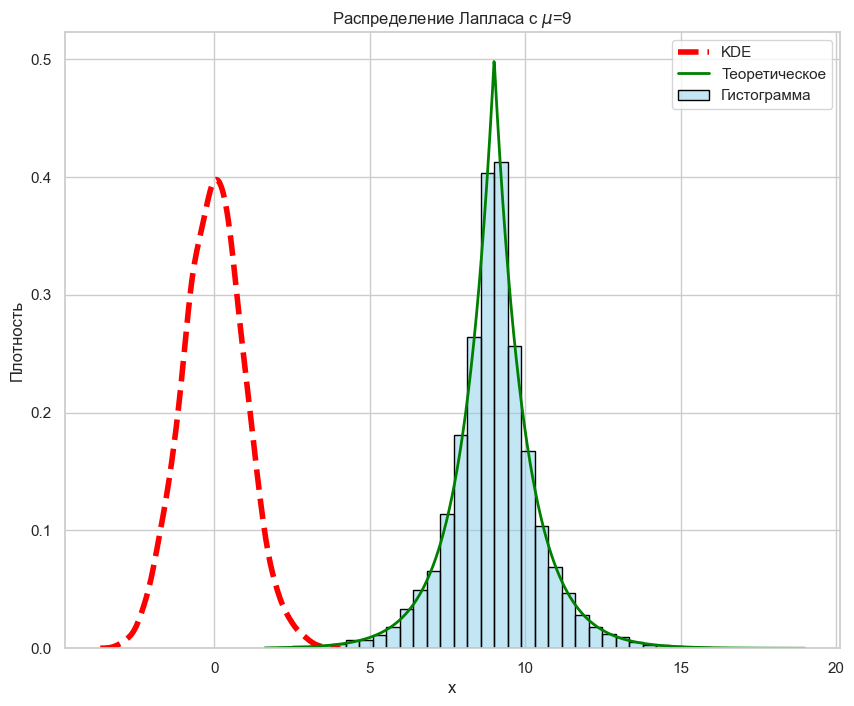

In [640]:
from scipy.stats  import laplace, norm, probplot

sns.set_style('whitegrid')
rng = np.random.default_rng(42)

MU = 9
N = 10_000
sample = laplace.rvs(loc=MU, scale=1, size=N, random_state=rng)

fig, ax = plt.subplots(figsize=(10, 8))

sns.histplot(
    sample, bins=40, stat='density',
    color='skyblue', edgecolor='black',
    alpha=0.5, ax=ax, label="Гистограмма"
)

sns.kdeplot(
    x, ax=ax, color='red',
    lw=4, linestyle='--',
    label="KDE"
)

xs = np.linspace(sample.min(), sample.max(), 1000)
ax.plot(xs, laplace.pdf(xs, loc=MU, scale=1),
        'green', lw=2, label="Теоретическое")
ax.set_title(f"Распределение Лапласа с $\\mu$=9")
ax.set_xlabel("x")
ax.set_ylabel("Плотность")
ax.legend()

plt.show()


Похожи ли гистограмма, KDE и теоретическая плотность? Чем KDE как приближение лучше и хуже чем гистограмма?

1) Да похожи, однако теоритическая явно выше в окрестности x = 9.
2) - KDE > Гистоограмма: она более гладка и лучше совпадает с теоретическим распределением. 
   - Гистограмма > KDE: лучше подоходит для дискрестных распределений. Лушче ведет себя при маленькой выборке



2. Сделайте выбору выборок размера 10000 на 10000. Если Вычисление застрянет, можно уменьшить до 1000 на 1000. Постройте выборку оценок. Для упрощения визуализации, посчитайте $\sqrt{N}(\hat{\mu} - \mu)$, где $N$ это размер выборки, $\hat{\mu}$ это оценка, а $\mu$ --- параметр. Визуализируйте эту выборку гистограммой и KDE

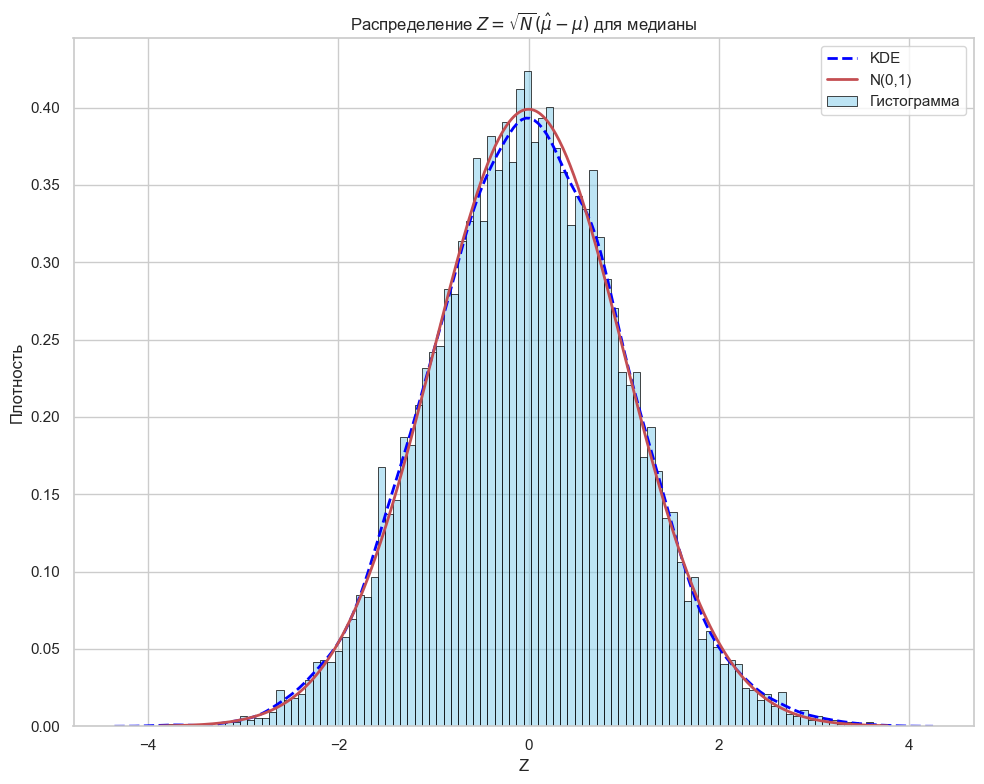

In [641]:
N = 10_000
M = 10_000
sample = laplace.rvs(loc=MU, scale=1, size=(M, N), random_state=rng)
mu_hat = np.median(sample, axis=1)
Z = np.sqrt(N) * (mu_hat - MU)
fig, ax = plt.subplots(figsize=(10, 8))

sns.histplot(Z, bins=100, stat='density', alpha=0.55,
             color='skyblue', edgecolor='black', ax=ax, label='Гистограмма')
sns.kdeplot(Z, ax=ax, color='blue', lw=2, linestyle='--', label='KDE')
xs = np.linspace(Z.min(), Z.max(), 400)
ax.plot(xs, norm.pdf(xs, loc=0, scale=1),
        'r', lw=2, label='N(0,1)')

ax.set_title(r'Распределение $Z=\sqrt{N}(\hat{\mu}-\mu)$ для медианы')
ax.set_xlabel('Z')
ax.set_ylabel('Плотность')
ax.legend()
plt.tight_layout()
plt.show()


Сделайте анализ и вывод полученного результата.

Теоретически оно должно сойтись к $N(0, 1)$ по распределению
Однако KDE и гистограмма слегка отличаются в окрестности 0, однако KDE делает это более сглажено

3. Сделайте предположение о виде распределения величины $\sqrt{N}(\hat{\mu} - \mu)$ и проверьте его при помощи QQ-plot. Если сможете, объясните теоретически, почему Ваше распределение верно. Для каких случаев исходного распределения (вместо Лапласа) должно было получиться в результате такое же распределение (как у Вас)?

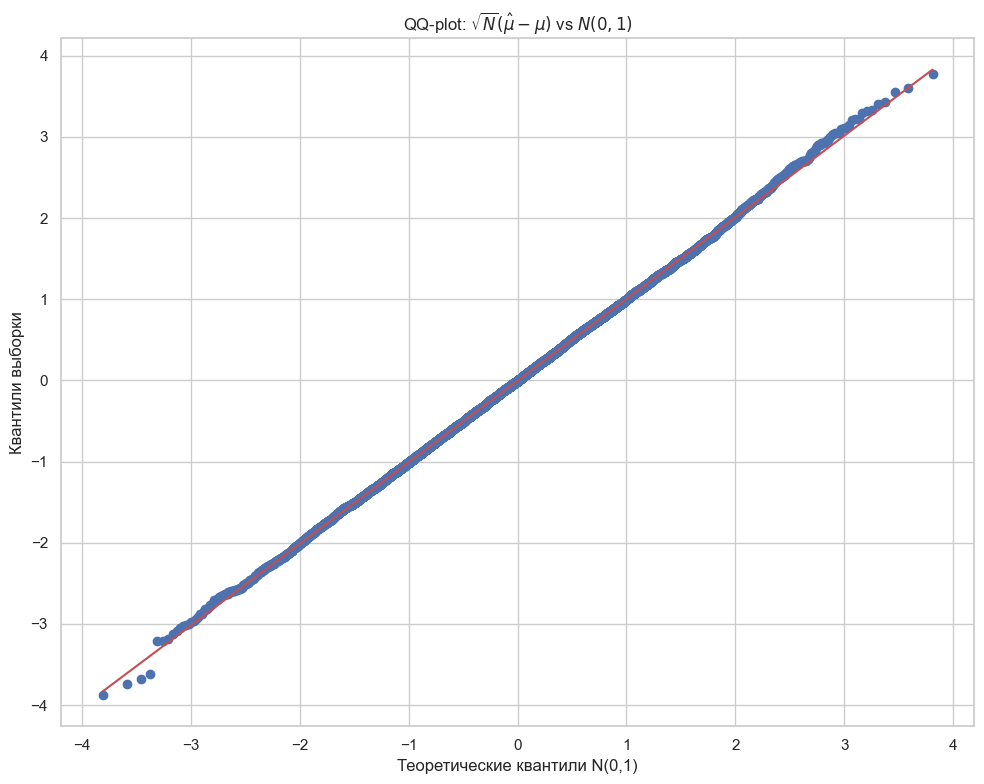

In [642]:
fig, ax = plt.subplots(figsize=(10, 8))
probplot(Z, dist="norm", plot=ax) 
ax.set_title(r'QQ-plot: $\sqrt{N}(\hat{\mu}-\mu)$ vs $N(0,1)$')
ax.set_xlabel('Теоретические квантили N(0,1)')
ax.set_ylabel('Квантили выборки')
plt.tight_layout()
plt.show()


Нетрудно заметить, что видимо оно сходится по распределению к нормальному распределению
Вероятно, такое распределение получится для всех выборок с всюду ненулевой плотностью

Какие выводы можно сделать, если точки в хвостах QQ-plot находятся выше/ниже своей прямой, как на картинке ниже? А если оба "хвоста" находятся с одной стороны прямой?


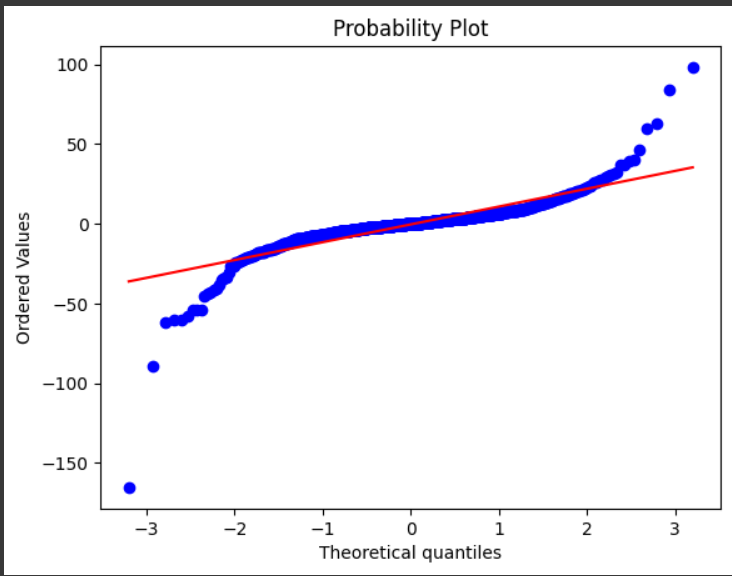

**Ответ:**
хвосты в разные стороны => хвосты более тяжелые или легкие
хвосты по одну сторону, значит что мы в целом не очень симметрично выстроились

4. Изучите, сходится ли оценка $\hat{\mu}$ к чему-то по вероятности с ростом N? Опишите, какой график Вы построите, чтобы это проверить и какие численные характеристики посчитаете для этого.

Посчитаем кумулятивно медианы на каждой итерации и посмотрим распределение отклонения

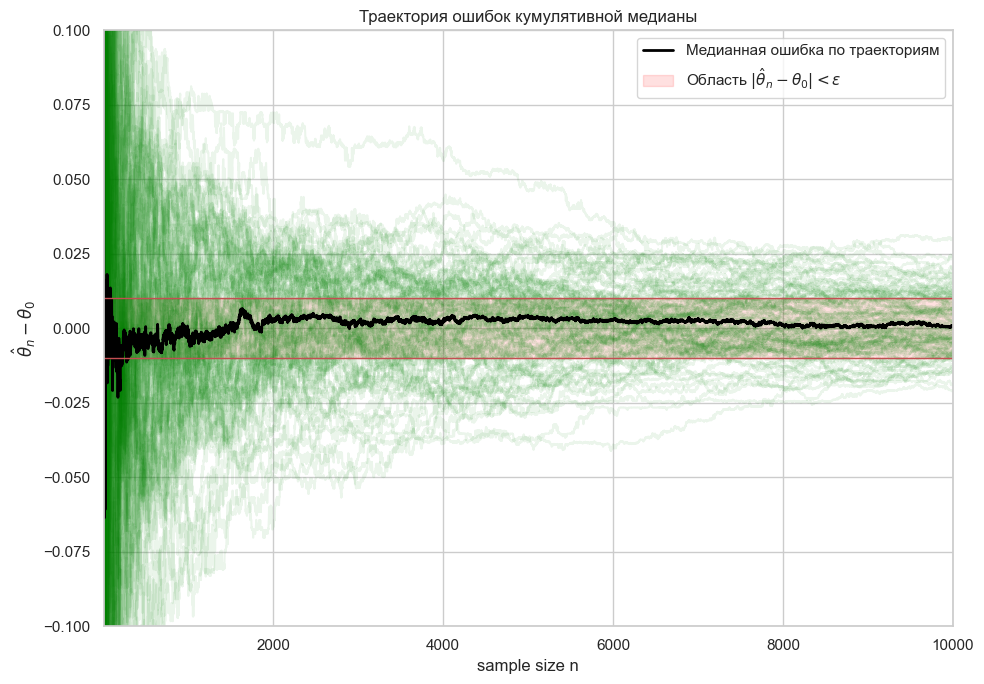

In [643]:
SAMPLE_COUNT = 100
EPS = 0.01
X = rng.laplace(loc=MU, scale=1.0, size=(SAMPLE_COUNT, N))

cum_meds = np.empty_like(X)

for k in range(N):
    cum_meds[:, k] = np.median(X[:,:k+1], axis=1)

errors = cum_meds - MU
median_error = np.median(errors, axis=0)
plt.figure(figsize=(10, 7))
plt.title("Траектория ошибок кумулятивной медианы")
for err in errors:
    plt.plot(range(1, N + 1), err, alpha=0.08, color="green")
plt.plot(range(1, N + 1), median_error, color="black", lw=2,
         label="Медианная ошибка по траекториям")
plt.hlines(y= EPS, xmin=1, xmax=N, color="r", linewidth=1)
plt.hlines(y=-EPS, xmin=1, xmax=N, color="r", linewidth=1)
plt.fill_between(
    np.arange(1, N + 1),
    -EPS, EPS,
    color='red', alpha=0.12,
    label=r'Область $|\hat{\theta}_n - \theta_0| < \epsilon$'
)
plt.xlim(1, N)
plt.ylim(-0.1, 0.1)
plt.xlabel("sample size n")
plt.ylabel(r"$\hat{\theta}_n - \theta_0$")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


На практике статисты не отличают состоятельность от сильной состоятельности (сходимость по вероятности и почти наверное) и проверяют оба свойства одинаково. Годится ли наш метод практической проверки для проверки сильной состоятельности? Как можно было бы проверить её качественнее?

**Ответ**: можно попрообовать подогнать процесс до того, что оно само ищет $\varepsilon$ и проверяет убывание, но кажется это тяжело
Можно в целом попробовать оценить монотоность плотности и тогда победа

5. Посчитайте среднее и выборочную дисперсию оценки для разных N. Как они ведут себя в пределе?

In [644]:
for n in [100, 1000, 5000, 10000, 20000, 50000, 100000]:
    med = np.median(laplace.rvs(loc=MU, scale=1, size=(1000, n), random_state=rng), axis=1)
    print(f'iter: {n}; mean : {med.mean()}; var : {med.var()}')


iter: 100; mean : 8.994957218296557; var : 0.01248403501519525
iter: 1000; mean : 9.000180475096256; var : 0.0010832671463674869
iter: 5000; mean : 9.000532960485387; var : 0.0002098432298419626
iter: 10000; mean : 8.999806407470247; var : 0.00010011996820388777
iter: 20000; mean : 8.999927227937153; var : 5.4491381067236926e-05
iter: 50000; mean : 9.00007487958514; var : 1.9656727455799696e-05
iter: 100000; mean : 8.999979085162114; var : 1.067419219584281e-05


Диспресия оценки сходится к нулю, а среднее оценок сходися в медиане

6. Постройте KDE величины $\sqrt{N}(\hat{\mu} - \mu)$ для разных $N$. Можно ли говорить о равномерной сходимости их к какой-то функции? Что это за функция?

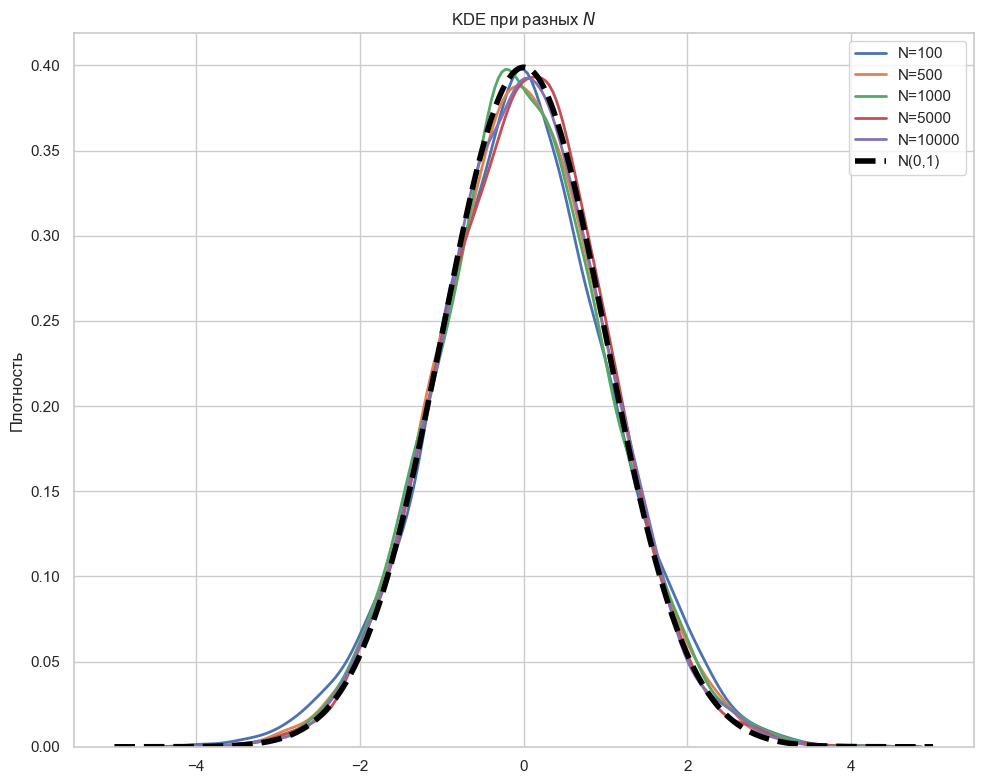

In [645]:
from scipy.stats import norm

N_list = [100, 500, 1000, 5000, 10_000]
M  = 5000
list = {}
for N in N_list:
    X = laplace.rvs(loc=MU, scale=1, size=(M, N), random_state=rng)
    mu_hat = np.median(X, axis=1)
    Z = np.sqrt(N) * (mu_hat - MU)
    list[N] = Z
grid = np.linspace(-5, 5, 400)
plt.figure(figsize=(10, 8))
for N in N_list:
    sns.kdeplot(list[N], lw=2, label=f'N={N}')

plt.plot(grid, norm.pdf(grid), 'black', lw=4, label='N(0,1)', linestyle="--")
plt.title(r'KDE при разных $N$')
plt.xlabel(''); plt.ylabel('Плотность')
plt.legend()
plt.tight_layout()
plt.show()


Полагаю, что о равномерной сходимости говорить в целом нельзя поскольку мы должны увлечивать M идейно, а тут может и поломаться. Мы же можем поменять что-то на множестве меры 0, и тогда равномерная сходимость пропадет, а с точки зрения статистики это ничего не поменяет

### Задача 2



В этой задаче мы будем работать с известной оценкой высокого качества --- Оценкой Максимального Правдоподобия (ОМП).

В этой задаче Вам предстоит:
- Записать правдоподобие как функцию для оптимизации
- Численно при помощи градиентного спуска найти оценку
- Изучить её предельное поведение

**В данной задаче разрешается не писать метод Ньютона и градиентный спуск руками, а пользоваться scipy.optimize**.

Правдоподобие выборки из непрерывного распределения это произведение плотностей её элементов (правдоподобие данной выборки --- функция, зависящая только от параметров распределения). Оценка максимального правдоподобия --- такое значение параметра, при котором правдоподобие максимально.

1. Выпишите функцию правдоподобия выборки из $N$ элементов. Какому уравнению удовлетворяет оценка (как максимум этой функции)? Глядя на получившуюся формулу объясните, в чём основной недостаток оценки ОМП, если выборка состоит из большого числа элементов?

**Ответ:**
$X_1, ..., X_N$ - iid выборка. Тогда $F_\theta(X_1, ..., X_N)= \prod_{i=1}^N p_\theta(X_i)$, где $p_\theta$ - плотность распределения, называется функцией правдоподобия $\\$
ОМП : $\hat{\theta}(X_1, ..., X_n) 
= \arg\max_{\theta \in \Theta} f_\theta(X_1, ..., X_n)$ $\\$
Соответственно, если $p_\theta$ дифференцируемая по $\theta$, то необходимо,  чтобы $\frac{\partial F_\theta}{\partial \theta}(X_1, ..., X_N) = \prod_{i=1}^N p_\theta(X_i) \cdot \sum_{i=1}^n \frac{\frac{\partial}{\partial \theta} p_\theta(X_i)}{p_\theta(X_i)} = 0$ .


Метод может не очень удобным поскольку мы явно используем большое перемножение, что может потенциально тратить много времени для больших выборок. Также мы перемножеаем вещи из [0, 1] и можем столкнуться с проблемой слишком малых значений с чем тяжело компьютеру потенцально работать.

2. Сгенерируйте выборку из распределения Коши с параметром сдвига 9 из 100 элементов.

Градиентный спуск это алгоритм поиска минимума функции, который "шагает" по минус градиенту (антиградиенту), пока тот не обнулится. Этот алгоритм имеет смысл, так как градиент указывает в сторону возрастания функции.

Попробуйте выписать производную функции правдоподобия для выборки из 100 элементов. Если у Вас это получилось, подайте эту производную в функцию scipy.optimize.minimize и посмотрите, какой результат эта функция Вам предложит.

Производную выписал ранее, производная плотности тривиальная: $
\frac{\partial}{\partial \theta} p_\theta(x)
= \frac{2(x-\theta)}{\pi\left(1+(x-\theta)^2\right)^2}.
$

In [646]:
from scipy.optimize import minimize

SIZE = 100
sample = sps.cauchy(loc=MU, scale=1).rvs(size=SIZE, random_state=rng)


def func_of_truth(theta) :
    return - np.prod(1.0 / (np.pi * (1 + (sample - theta)**2)))

def grad(theta):
    product = func_of_truth(theta)
    sigma = np.sum(2*(sample - theta) / (1 + (sample - theta)**2))
    return - product * sigma

minimize(func_of_truth, x0=np.median(sample), jac=grad)


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -5.209029486840075e-97
        x: [ 8.967e+00]
      nit: 0
      jac: [ 8.818e-97]
 hess_inv: [[1]]
     nfev: 1
     njev: 1

Если у Вас всё почему-то сломалось, объясните почему.

все получилось, но итераций как я понял призошло ноль, поскольку производная уже была маленькой в медиане, т.к мы перемножаем плотности, которые на отрезке от [0, 1], соотвественно градиент заведомо довольно мал, из-за чего мы всегда будем останвливаться в точке x0, которую указваем в парметрам minimize

**Ответ:**

3. Вместо максимизации правоподобия статисты минимизируют минус логарифм правдоподобия (называя его логправдоподобием). Объясните, чем это лучше.

Посчитайте производную минус логарифма правдоподобия и подайте её снова в scipy.optimize.minimize. Предложите хорошую стартовую точку для метода? Как Вам кажется, какая оценка параметра сдвига может быть хорошим стартом для поиска ОМП?

лог-функция правдоподобия: $\sum_{i=1}^N \log p_\theta(X_i) = Nlog{\pi} + \sum_{i=1}^N log(1 + (X_i - \theta)^2)\\$ 
Производная:$ \sum_{i=1}^N \frac{2(X_i - \theta)}{1 + (X_i - \theta)^2} \\$ 
все указано с учетом минуса

метод работает и даже хорошо, поскольку тут тяжело градиент вообще ненулевой вне точек экстремума, т.к мы избавились от произведения плотностей
нетрудно проверить, что в нашем случае мы попадаем правильно при любой начальной точке, однако быстрее было бы если в качестве стартовой точки мы выбирали бы медиану

In [647]:
def log_func_of_truth(theta, data):
    return (np.sum(np.log(1.0 + (data - theta)**2)) + 100 * np.log(np.pi)) 

def log_grad(theta, data):
    return np.sum( 2.0*(data - theta) / (1.0 + (data - theta)**2)) * -1
minimize(log_func_of_truth, args=(sample, ), x0=np.median(sample), jac=log_grad)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 221.6714069153606
        x: [ 9.001e+00]
      nit: 3
      jac: [-4.046e-10]
 hess_inv: [[ 2.045e-02]]
     nfev: 5
     njev: 5

4. Найдите ОМП для размеров выборки от 10 до 1000 с какой-то сеткой. Изобразите их на графике. Сходятся ли они к чему-то?

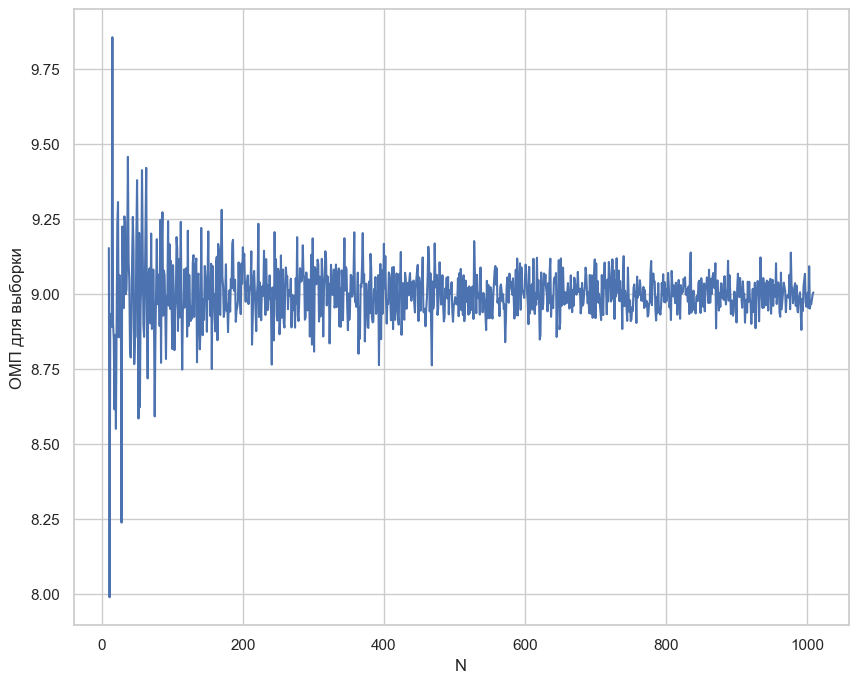

In [648]:
samples = np.zeros(shape=(1000,))
for n in range(10, 1000 + 10):
    sample = sps.cauchy(loc=MU, scale=1).rvs(size=n, random_state=rng)
    x0 = np.median(sample)
    res = minimize(log_func_of_truth, x0=x0, args=(sample,), jac=log_grad)
    samples[n - 10] = res.x[0]
plt.figure(figsize=(10, 8))
plt.plot(np.arange(10, 1000 + 10), samples, label='ОМП в зависимости от N')
plt.xlabel('N')
plt.ylabel('ОМП для выборки')
plt.grid(True)
plt.show()

Верю, что при росте N они сойдутся к 9 (то есть истинному значению $\theta$)

5. Для $N = 1000$ изобразите KDE и/или QQ-plot величины $\sqrt{N}(\hat{\theta} - \theta)$ и выясните, к какому предельному распределению оно сходится.

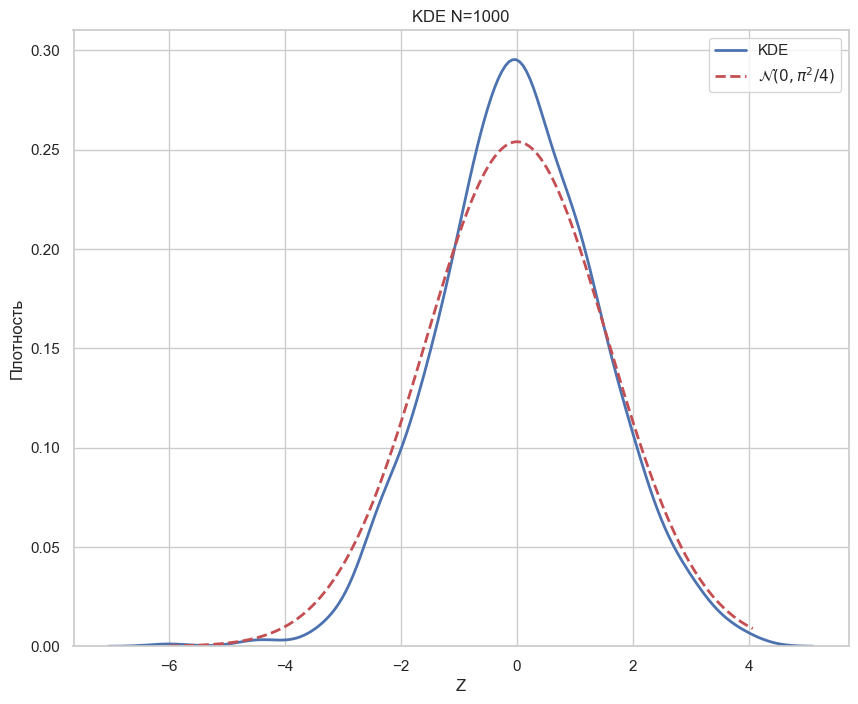

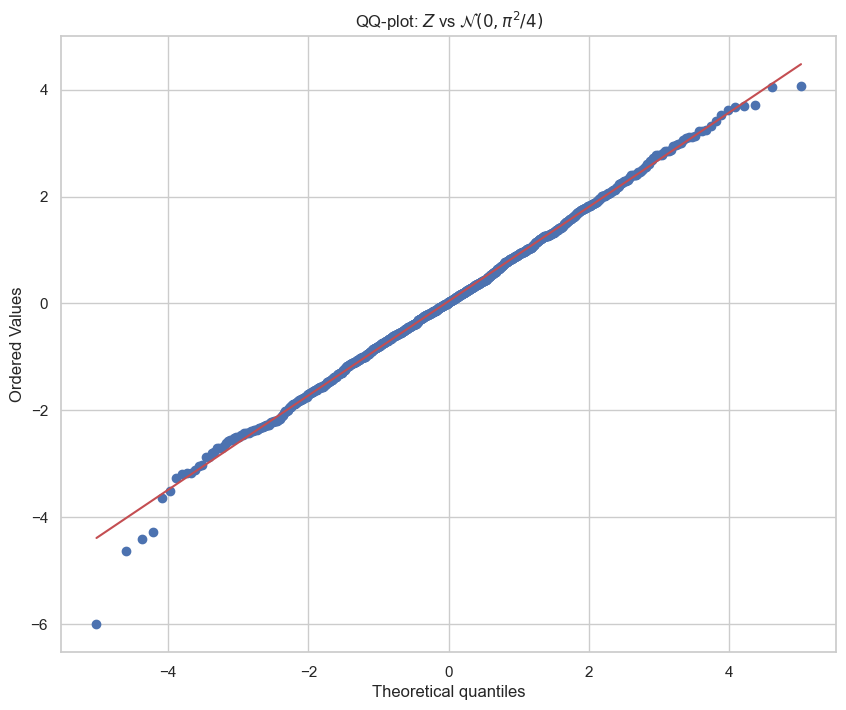

In [649]:
samples = np.zeros(1000)
N = 1000

for i in range(1000):
    sample = sps.cauchy(loc=MU, scale=1).rvs(size=n, random_state=rng)
    x0 = np.median(sample)
    res = minimize(log_func_of_truth, x0=x0, args=(sample,), jac=log_grad)
    samples[i] = res.x[0]

Z = np.sqrt(N) * (samples - MU)
plt.figure(figsize=(10, 8))
sns.kdeplot(Z, lw=2, label='KDE')
xs = np.linspace(Z.min(), Z.max(), 400)
plt.plot(xs, norm.pdf(xs, loc=0, scale=np.pi/2),
         'r--', lw=2, label=r'$\mathcal{N}(0,\pi^2/4)$')
plt.title(r'KDE N=1000')
plt.xlabel("Z")
plt.ylabel("Плотность")
plt.legend()
plt.show()
plt.figure(figsize=(10,8))
probplot(Z, dist=norm(loc=0, scale=np.pi/2), plot=plt)
plt.title(r'QQ-plot: $Z$ vs $\mathcal{N}(0,\pi^2/4)$')
plt.show()


по теореме о выборочном квантиле при $p = 1/2$ и $p(\theta) = 1 / \pi$ получаем что сходится к $N(0,  \pi ^ 2 / 4)$ но хвосты получились чуть тяжелее, не знаю что не так

### Задача 3

В этой задаче мы изучим способы сравнения оценок между собой.

Мы будем оценивать параметр $\theta$ распределения $U[0, \theta]$ следующими способами: $2\overline{X}$, $\frac{n+1}{n} X_{(n)}$, $(n+1)X_{(1)}$, $\overline{X} + X_{(n)}/ 2$ и $X_{(1)}+X_{(n)}$. Зафиксируем конкретное значение параметра $\theta = 9$.

В этой задаче Вам предстоит:
- Промоделировать и сравнить все предложенные оценки
- Посчитать численный риск и убедиться, что это разумная метрика качества оценки
- Применить равномерный и байесовский подходы к сравнению оценок

1. Промоделируйте каждую из оценок. Постройте все оценки на графике в единых осях или на таблице графиков с общими осями. Если будут расхождения в масштабах, ниже постройте отдельные графики для оценок с разными подходящими масштабами.

2. Изучите, как меняются распределения оценок с изменением размера выборки. Для этого постройте KDE для 4-5 разных размеров на одном графике. Для каждой оценки сделайте отдельный такой график. Сделайте выводы о предельном поведении оценок.

3. Сделайте промежуточный вывод по графикам какая оценка самая лучшая и обоснуйте его. Используйте для этого все полученные результаты.

4. Для каждой оценки для квадратичной функции потерь найдите эмпирический риск. Для первых трёх оценок посчитайте точный риск. Интеграл можно брать руками, вольфрамом или функцией scipy.integrate.quad. Сделайте выводы о том, хорошо ли эмпирический риск приближает точный риск. После этого сравните оценки на основании эмпирического риска. Совпадает ли порядок с тем, что Вы сделали глядя на графики? Почему?

Какой характеристикой распределения является квадратичный риск? Какому свойству графика плотности оценки она соответствует?

**Ответ**:

5. Предложите 2 другие осмысленные функции потерь (какие свойства должны быть у функции, чтобы быть осмысленной?) и посчитайте эмпирические риски. Будут ли оценки сравниваться также или нет?

6. До текущего момента мы сравнивали риск для конкретного значения параметра. Если для каждого значения параметра риск одной оценки оказывается лучше, чем другой, то первая оценка считается лучше в равномерном подходе. Хоть у нас именно этот случай и реализовался, это редкий случай. Часто оказывается, что для одних значений параметров одни оценки лучше других, а для других значений наоборот. В этом случае используют байесовский подход.

Предложите некоторую плотность распределений самого параметра, просемплируйте из неё 10-100 значений и посчитайте байесовский эмпирический риск. Байесовский риск это интеграл (в нашем случае среднее) риска при случайном значении параметра. Объясните, из каких прикладных соображений следует выбирать плотность распределения параметра?

Сделайте выводы о том, какая оценка оказалась лучше. В выводе отметьте, с какой скоростью сходились точные риски первых трёх оценок и как это влияет на точность оценки.

**Вывод:**

### Задача 4

В этой задаче мы проверим теорему Гливенко-Кантелли, как результат, гарантирующий что эмпирически посчитанные величины хорошо приближают теоретические.

В этой задаче Вам предстоит:
- Построить эмпирическую функцию распределения для разных размеров выборки и сравнить её с теоретической функцией.
- Построить одну из ключевых статистик: статистику Колмогорова и изучить её предельные свойства

1. Для стандартного нормального распределения сгенерируйте 10000 выборок размера 10000. Для каждой выборки посчитайте эмпирическую функцию распределения для некоторой сетки. Напомним, что эмпирическая функция распределения (ЭФР) это $\hat{F}(x) = \frac{1}{n}\sum\limits_{i=1}^n I(x \leq X_i)$, где $X_i$ это элемент выборки.

In [650]:
X = sps.norm().rvs(size=(10_000, 10_000))
X_grid = np.linspace(-5, 5, 400)
emper_F = np.zeros((10_000, 400))
for n in range(400):
    emper_F[:, n] = np.mean(X <= X_grid[n], axis=1)


Для некоторых размеров выборки (лучше не больше 6 разных) постройте на графике ЭФР и теоретическую функцию распределения. Как ведёт себя ЭФР с ростом параметра?

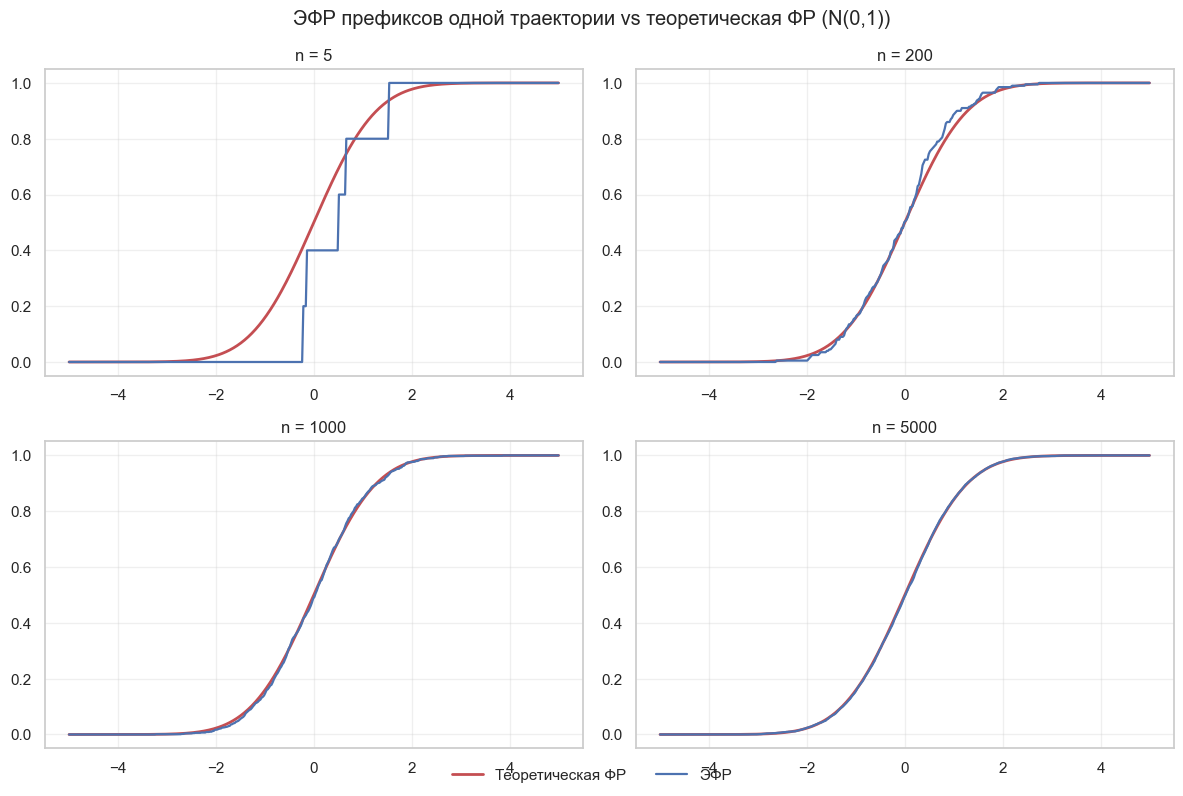

In [651]:
n_list = [5, 200, 1000, 5000]
x1 = X[0]

def ecdf(sample, n, xs):
    return (sample[:n, None] <= xs[None, :]).mean(axis=0)

normal = norm.cdf(X_grid)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, n in zip(axes, n_list):
    F = ecdf(x1, n, X_grid)
    ax.plot(X_grid, normal, 'r', lw=2, label='Теоретическая ФР')
    ax.plot(X_grid, F,  'b', lw=1.6, label=f'ЭФР')
    ax.set_title(f'n = {n}')
    ax.grid(True, alpha=0.3)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False)

fig.suptitle('ЭФР префиксов одной траектории vs теоретическая ФР (N(0,1))')
plt.tight_layout()
plt.show()

очевидно, ЭФР сглаживается и в каком-то смысле апроксимирует теоритическую ФР

Теорема Гливенко-Кантелли утверждает, что $D_n = \sup\limits_{x \in \mathbb{R}}|\hat{F}(x) - F(x)|$ стремится к нулю почти наверное. Посчитайте, чему равен этот супремум численно и как он себя ведёт с ростом $n$. Проверили ли мы теорему?

In [652]:
M = X.shape[0]
vals_med = []
n_dist = norm.cdf(X_grid)

for n in n_list:
    diffs = np.empty(M, dtype=float)
    for i in range(M):
        Fn = ecdf(X[i], n, X_grid)             
        diffs[i] = np.max(np.abs(Fn - n_dist))    
    vals_med.append(np.median(diffs))

for n, md in zip(n_list, vals_med):
    print(f"n={n:5d}  median={md:.6f}")

n=    5  median=0.338385
n=  200  median=0.054950
n= 1000  median=0.024519
n= 5000  median=0.010906


В целом-то результат соответствует теорме Гливенко-Кантелли, однако утверждать о верности теоремы рано, поскольку по сути мы прошли эмпирический тест, а в теореме говорится о почти-наверное, что на порядок сильнее

Промоделируйте статистику $\sqrt{n}D_n$ для n = 10000 и постройте её KDE. Затем промоделируйте эту же статистику не для нормального распределения, а для 3 других любых предложенных Вами распределений. Если вычисления застрянут, можете уменьшить число выборок или размер выборки. Будет ли итоговая плотность такой же?

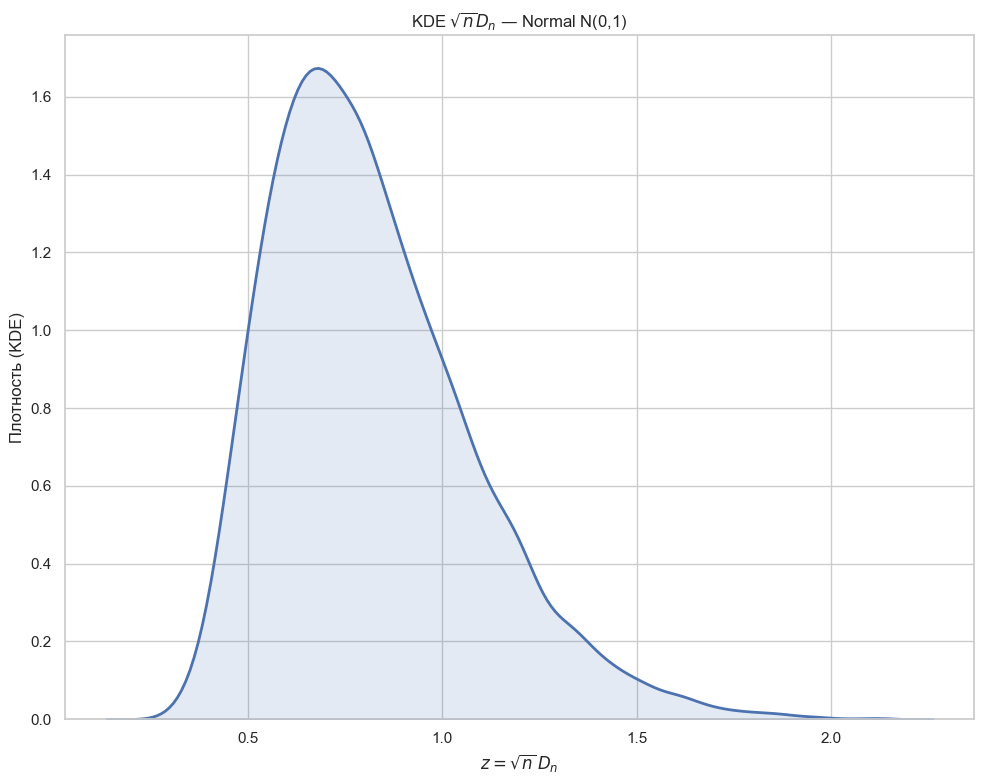

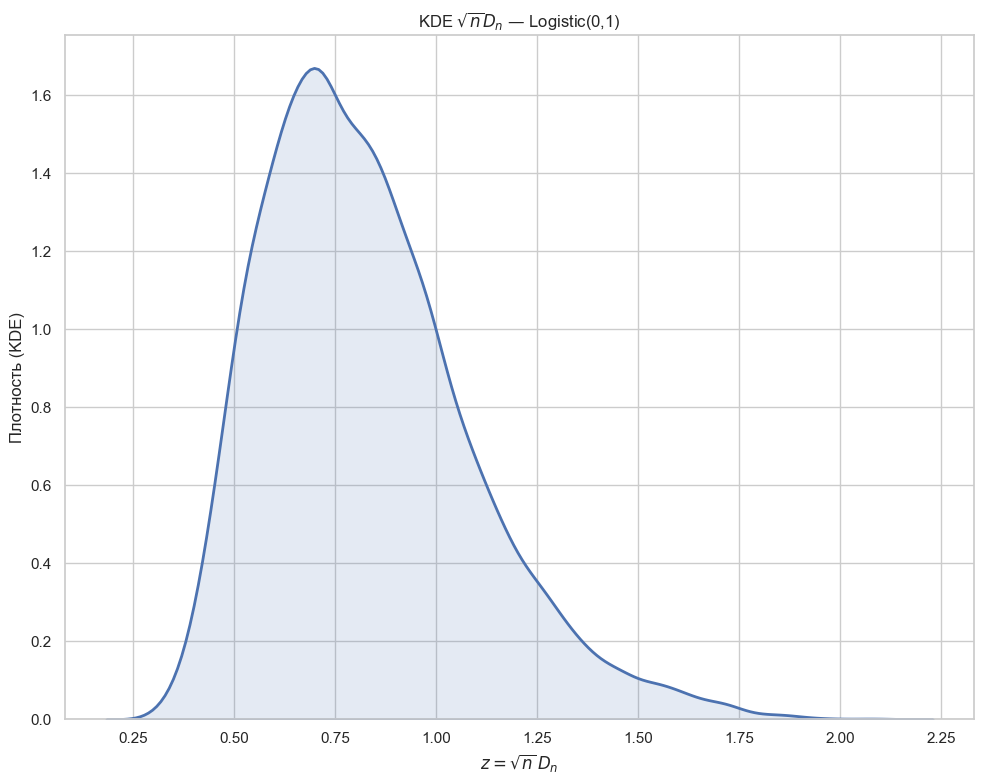

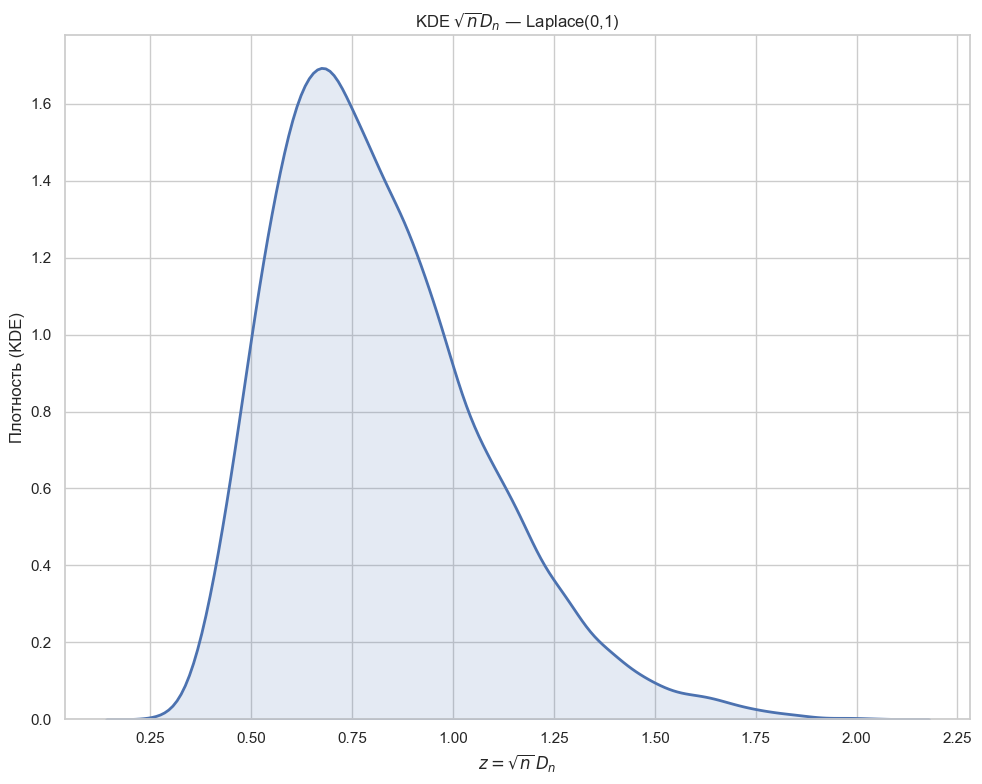

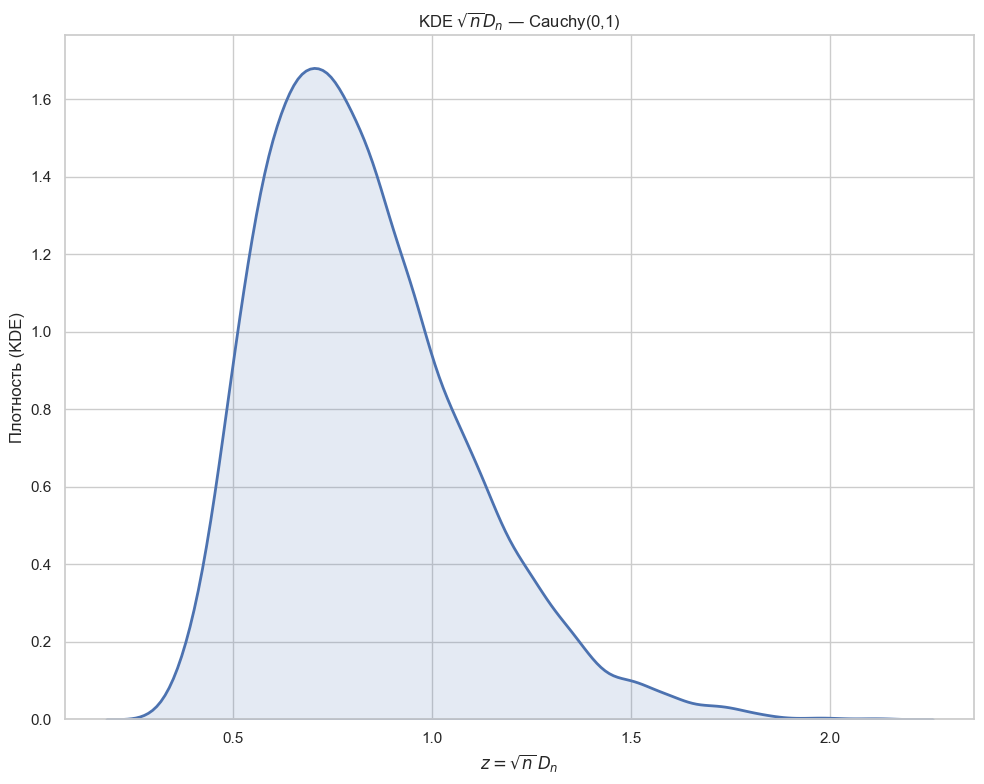

In [653]:
from scipy.stats import norm, laplace, cauchy, logistic

def D_grid(X, x_grid, cdf_func):
    M, n = X.shape
    F_grid = cdf_func(x_grid)         
    D = np.zeros(M)
    for x0, F0 in zip(x_grid, F_grid):
        Fn_col = (X <= x0).mean(axis=1)
        np.maximum(D, np.abs(Fn_col - F0), out=D)
    return D

def norm_grid(M=10_000, n=10_000, x_grid=None, rng=None):
    X = norm.rvs(size=(M, n), random_state=rng)
    D = D_grid(X, x_grid, norm.cdf)
    return np.sqrt(n) * D

def logistic_grid(M=10_000, n=10_000, x_grid=None, rng=None):
    X = logistic.rvs(size=(M, n), random_state=rng)
    D = D_grid(X, x_grid, logistic.cdf)
    return np.sqrt(n) * D

def laplace_grid(M=10_000, n=10_000, x_grid=None, rng=None):
    X = laplace.rvs(size=(M, n), random_state=rng)
    D = D_grid(X, x_grid, laplace.cdf)
    return np.sqrt(n) * D

def cauchy_grid(M=10_000, n=10_000, x_grid=None, rng=None):
    X = cauchy.rvs(size=(M, n), random_state=rng)
    D = D_grid(X, x_grid, cauchy.cdf)
    return np.sqrt(n) * D

x_grid = np.linspace(-5, 5, 400) 
M, n = 10_000, 10_000

Z_norm = norm_grid(M, n, x_grid, rng)
Z_logistic = logistic_grid(M, n, x_grid, rng)
Z_laplace = laplace_grid(M, n, x_grid, rng)
Z_cauchy = cauchy_grid(M, n, x_grid, rng)

def plot_kde_single(Z, title):
    plt.figure(figsize=(10,8))
    sns.kdeplot(Z, lw=2, fill=True, alpha=0.15)
    plt.xlabel(r'$z=\sqrt{n}\,D_n$')
    plt.ylabel('Плотность (KDE)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_kde_single(Z_norm, r'KDE $\sqrt{n}D_n$ — Normal N(0,1)')
plot_kde_single(Z_logistic, r'KDE $\sqrt{n}D_n$ — Logistic(0,1)')
plot_kde_single(Z_laplace, r'KDE $\sqrt{n}D_n$ — Laplace(0,1)')
plot_kde_single(Z_cauchy, r'KDE $\sqrt{n}D_n$ — Cauchy(0,1)')

Кажется, это все дело сходится к одному замысловатому распределению 

На просторах интернета, в беседе с умными людьми или на скале в пещере найдите, к чему сходится по распределению статистика $\sqrt{n}D_n$? Какое есть применение у этого крупного результата?

**Ответ:** на просторах интернета утверждают нечто такое: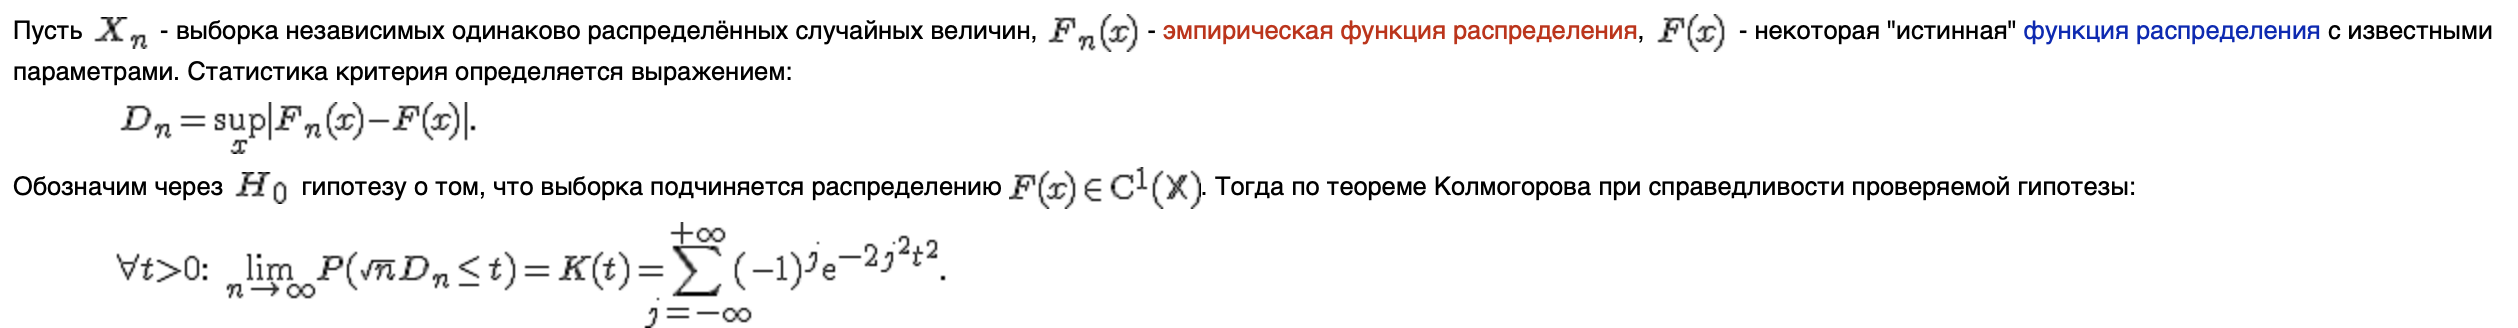
вероятно, блгагодаря этому можно строить "доверительные" интервалы и прочие штуки как с ЦПТ в ТВ

Если Вы нашли ответ на вопрос выше, проверьте что Ваше распределение совпадает с теоретическим пределом при помощи QQ-plot

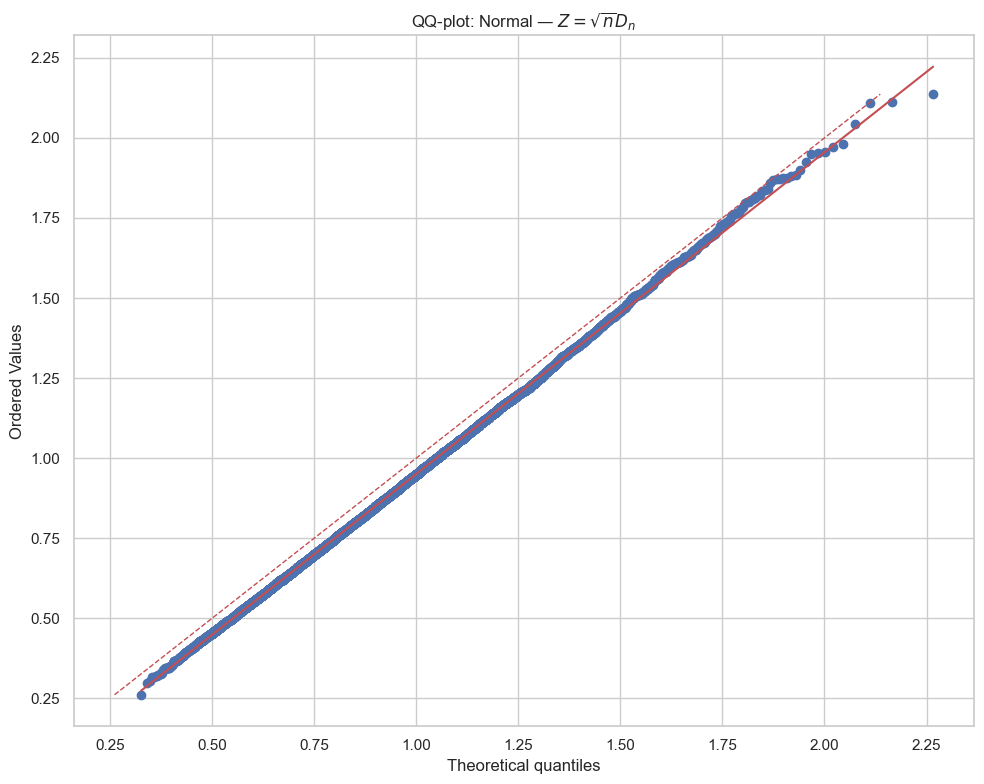

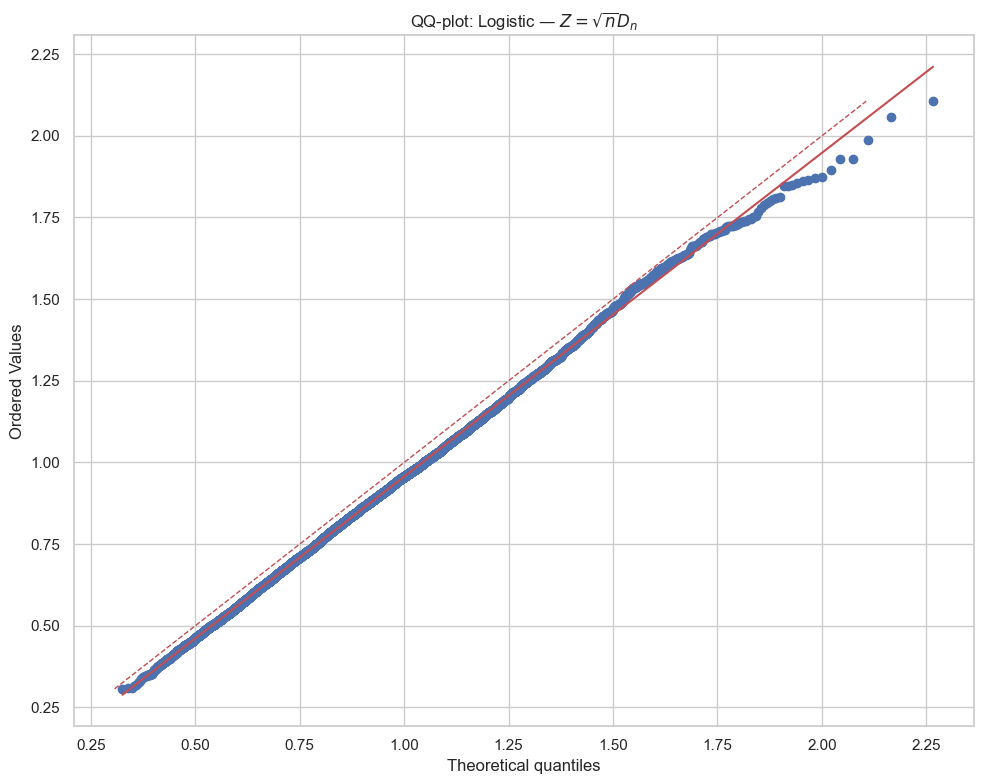

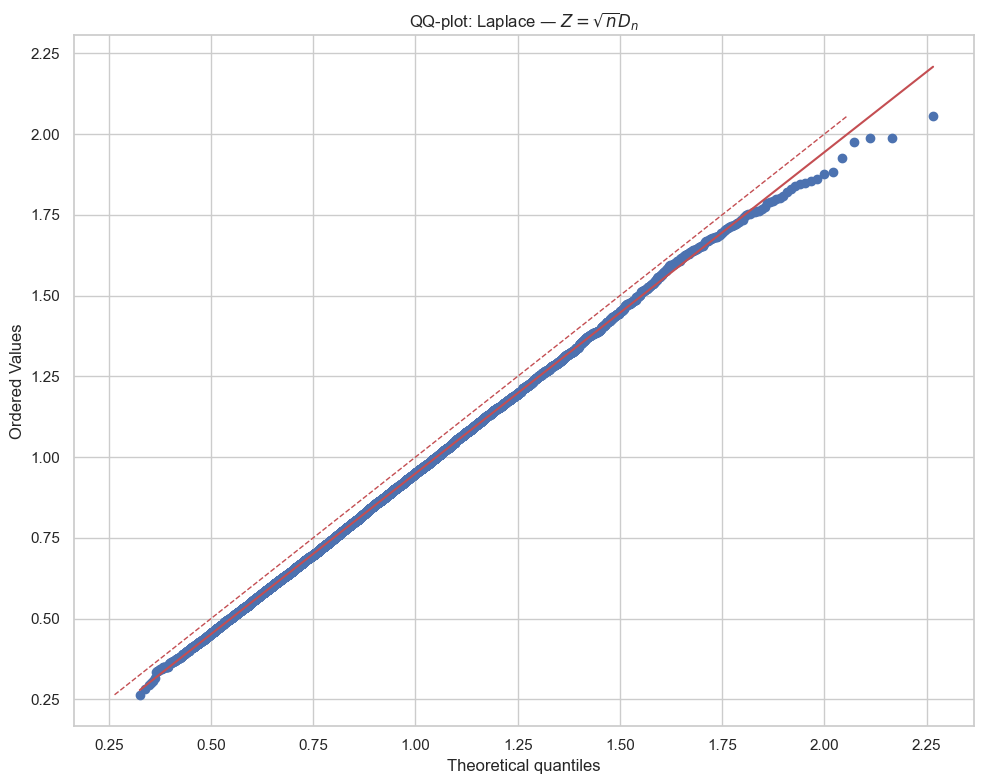

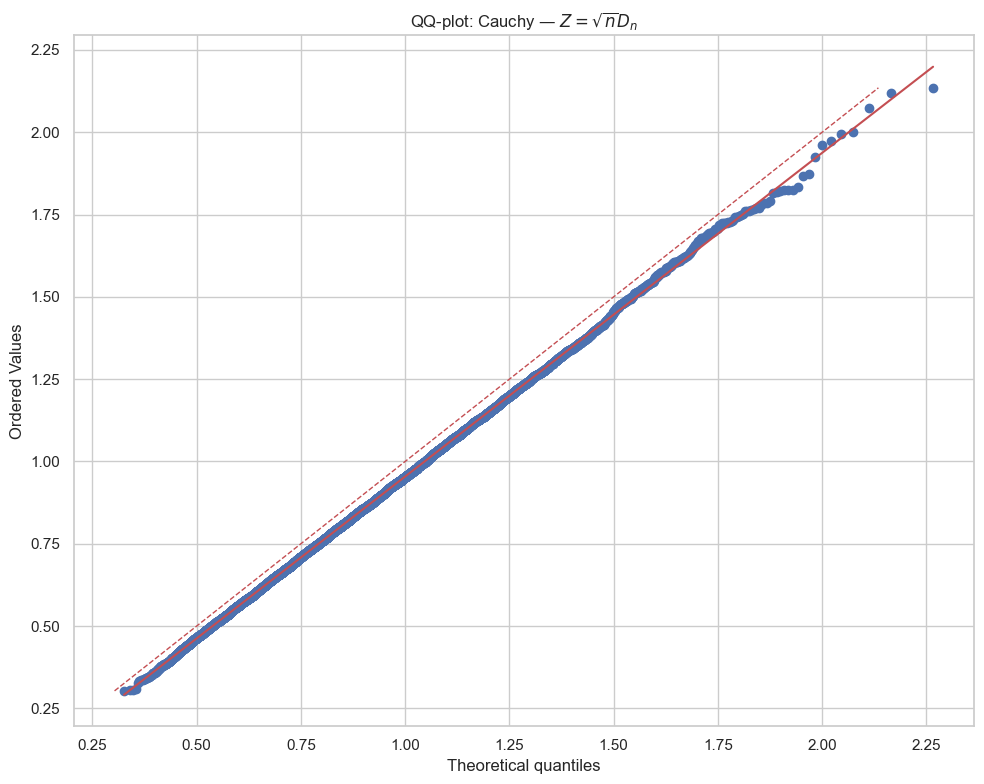

In [654]:
def qqplot(Z, title):
    fig, ax = plt.subplots(figsize=(10,8))
    probplot(Z, dist=sps.kstwobign,plot=ax)
    lo, hi = np.min(Z), np.max(Z)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(title)
    plt.tight_layout(); plt.show()

qqplot(Z_norm,     r'QQ-plot: Normal — $Z=\sqrt{n}D_n$')
qqplot(Z_logistic, r'QQ-plot: Logistic — $Z=\sqrt{n}D_n$')
qqplot(Z_laplace,  r'QQ-plot: Laplace — $Z=\sqrt{n}D_n$')
qqplot(Z_cauchy,   r'QQ-plot: Cauchy — $Z=\sqrt{n}D_n$')

Ну у меня слегка результаты ниже, чем y = x, но это отличается на константу так что все отлично и видимо теория и правда работает, а именно сходимость к распределению Колмогорова(надеюсь ее так называют)

### Задача 5

В этой задаче мы проверим предельные свойства оценок и познакомимся с таким понятием как гипернормальная сходимость.

В этой задаче Вам предстоит:
- Изучить предельные распределения и скорости сходимости разных оценок
- Понять как теоретические результаты могут предложить гарантию качества на практике

1. Сгенерируйте $N=400$ выборок из равномерного распределения $\mathrm U{[0, \theta]}$ для $\theta=9$ размера $n=40$. Посчитайте оценки $\hat\theta = 2\overline{X}, \ \theta^* = \frac{n+1}{n} X_{(n)}$ и нарисуйте их KDE на одном графике.

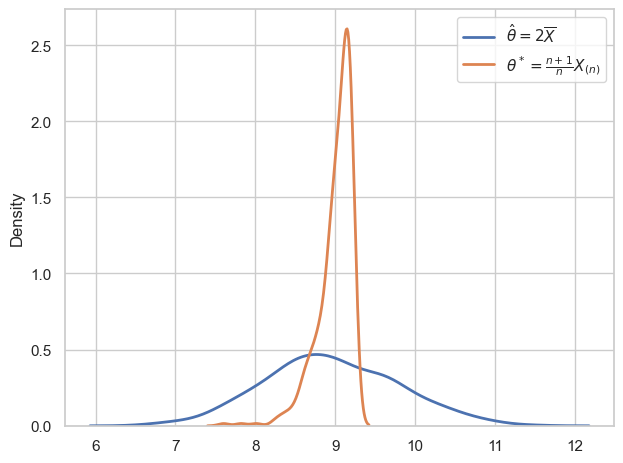

In [655]:
THETA = 9
N, M = 400, 40
X = sps.uniform(loc=0, scale=THETA).rvs(size=(N, M), random_state=rng)

theta_hat = 2 * X.mean(axis=1)
theta_star = (M + 1.0) / M * X.max(axis=1)

sns.kdeplot(theta_hat, lw=2, label=r'$\hat{\theta}=2\overline{X}$')
sns.kdeplot(theta_star, lw=2, label=r'$\theta^*=\frac{n+1}{n}X_{(n)}$')
plt.legend()
plt.tight_layout()
plt.show()

2. Численно и визуально проверьте, что обе оценки сходятся по вероятности к своему параметру.

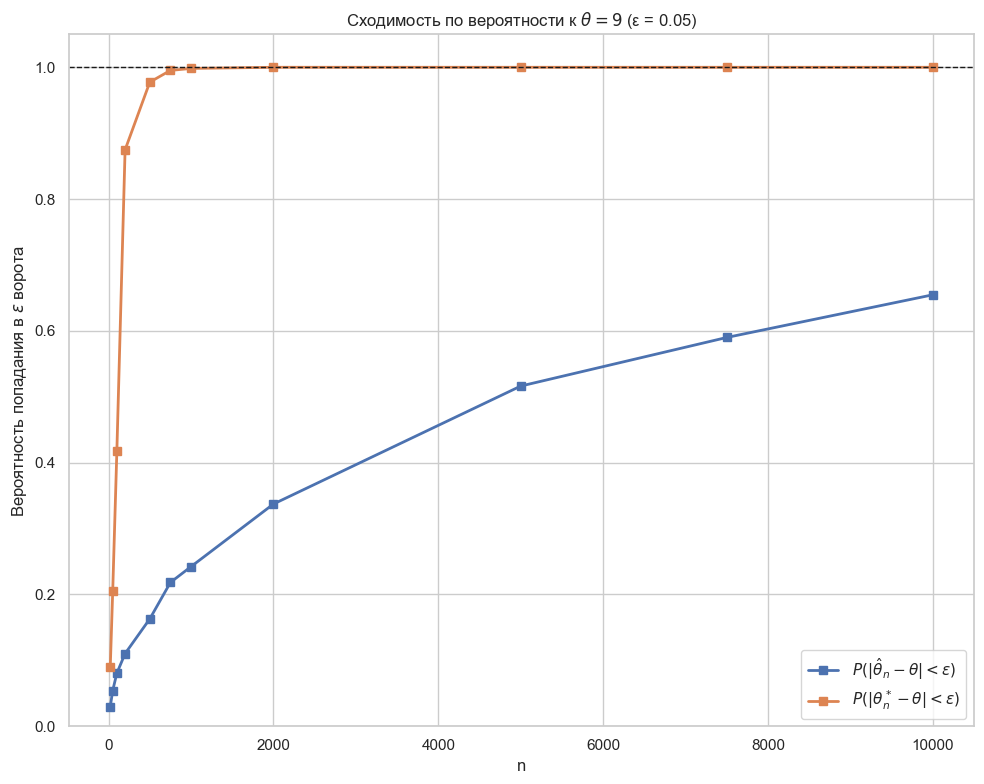

In [656]:
Ns = [20, 50, 100, 200, 500, 750, 1000, 2000, 5000, 7500, 10000]
M  = 4000
EPS = 0.05

p_in_hat  = [] 
p_in_star = []

for n in Ns:
    X = sps.uniform(loc=0, scale=THETA).rvs(size=(M, n), random_state=rng)

    theta_hat  = 2 * X.mean(axis=1)
    theta_star = ((n + 1)/n) * X.max(axis=1)

    p_in_hat.append( np.mean(np.abs(theta_hat  - THETA) < EPS) )
    p_in_star.append(np.mean(np.abs(theta_star - THETA) < EPS) )

plt.figure(figsize=(10,8))
plt.plot(Ns, p_in_hat,  marker='s', lw=2, label=r'$\,P(|\hat\theta_n-\theta|<\varepsilon)$')
plt.plot(Ns, p_in_star, marker='s', lw=2, label=r'$\,P(|\theta_n^*-\theta|<\varepsilon)$')
plt.axhline(1.0, color='k', ls='--', lw=1)
plt.ylim(0, 1.05)
plt.xlabel('n')
plt.ylabel(r'Вероятность попадания в $\varepsilon$ ворота')
plt.title(rf'Сходимость по вероятности к $\theta=9$ (ε = {EPS})')
plt.legend()
plt.tight_layout()
plt.show()

3. Промоделируйте статистики $\sqrt{n} (\hat\theta - \theta)$ и $\theta - n  (\theta^* - \theta)$. К чему сходятся их распределения с ростом $n$?

 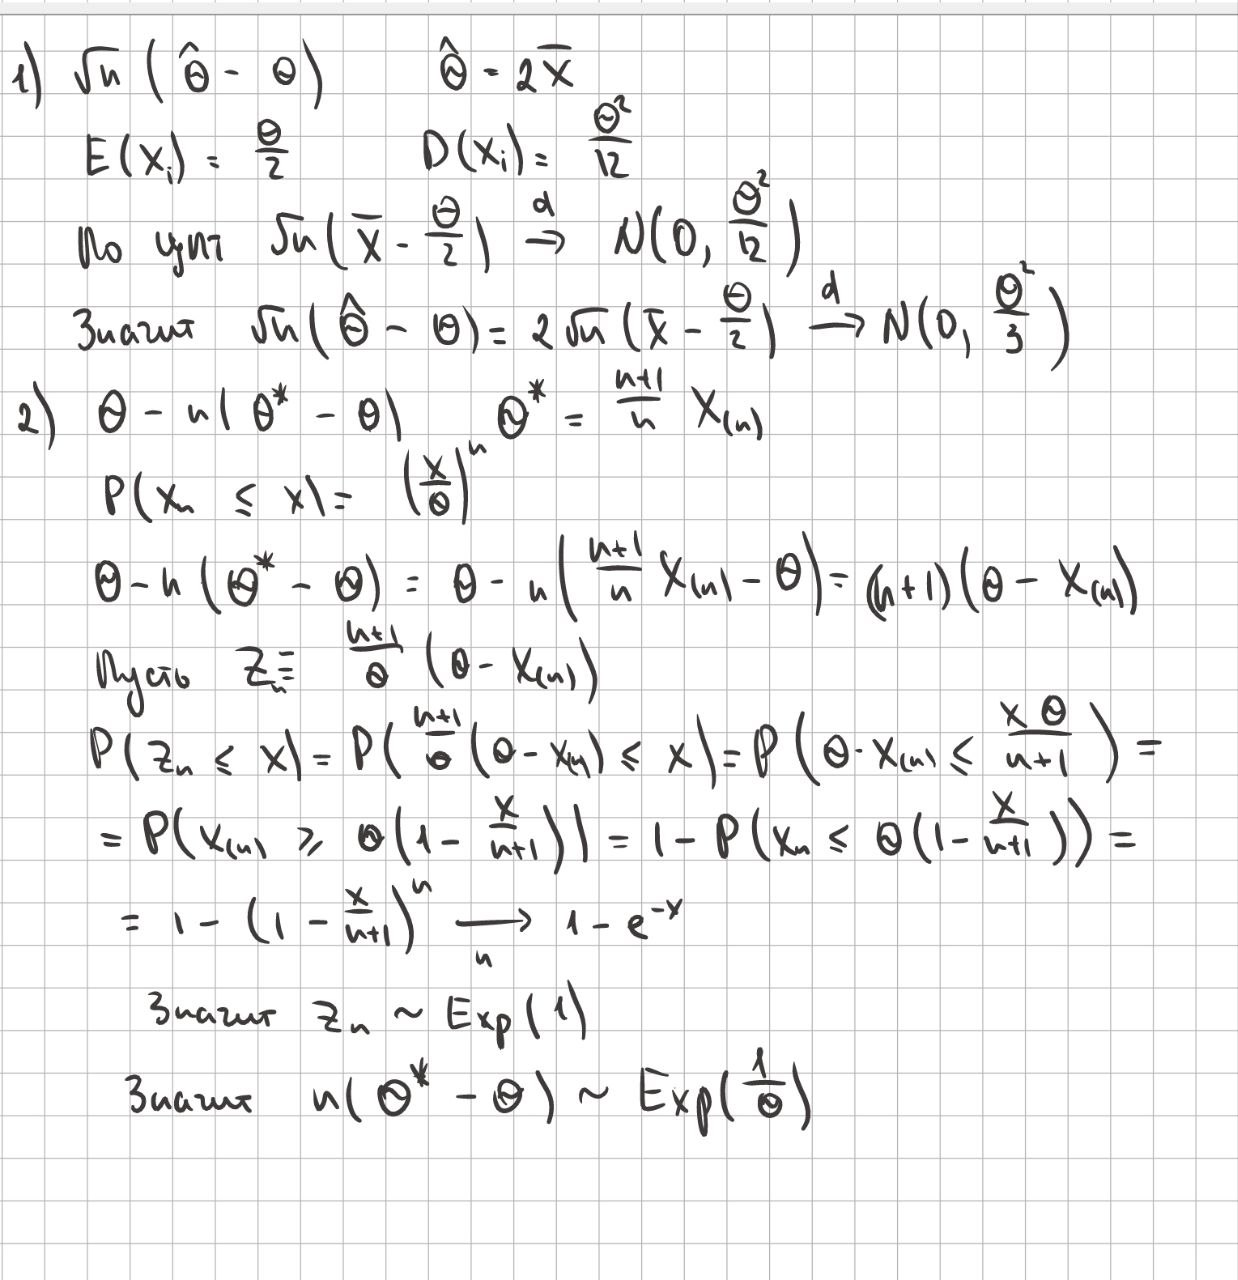

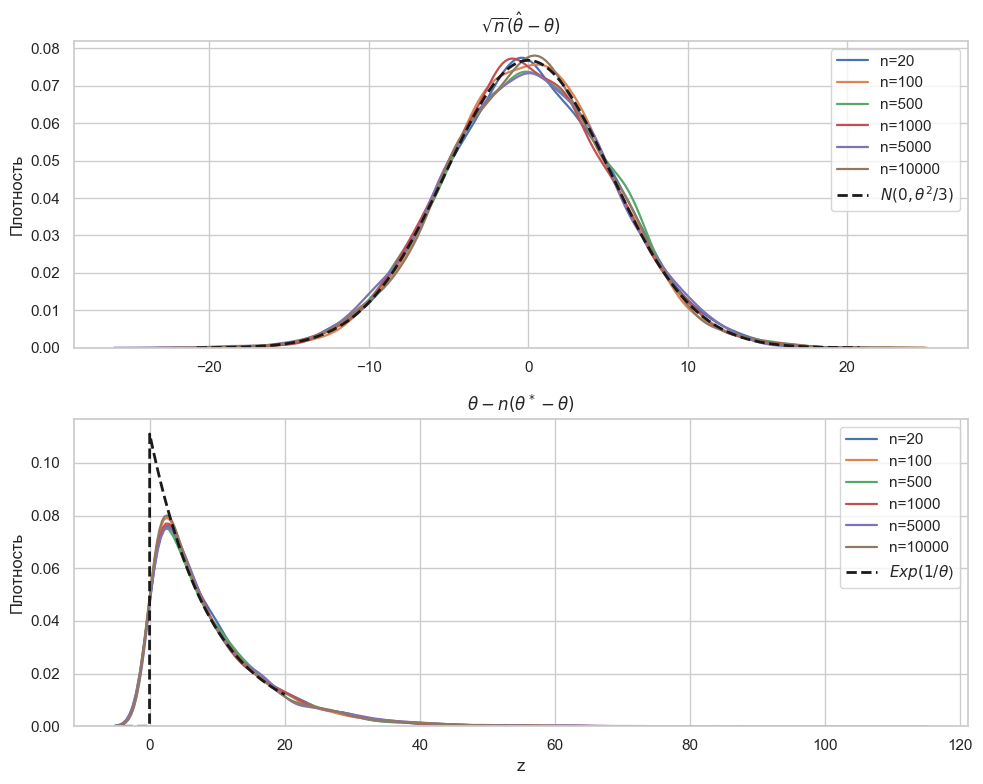

In [657]:
Ns = [20, 100, 500, 1000, 5000, 10000]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for n in Ns:
    X = sps.uniform(loc=0, scale=THETA).rvs(size=(M, n), random_state=rng)
    theta_hat  = 2 * X.mean(axis=1)
    theta_star = ((n + 1)/n) * X.max(axis=1)
    Z1 = np.sqrt(n) * (theta_hat - THETA)
    Z2 = THETA - n * (theta_star - THETA)
    sns.kdeplot(Z1, ax=axes[0], lw=1.6, label=f'n={n}')
    sns.kdeplot(Z2, ax=axes[1], lw=1.6, label=f'n={n}')
xs1 = np.linspace(-4*THETA/np.sqrt(3), 4*THETA/np.sqrt(3), 400)
axes[0].plot(xs1, sps.norm(loc=0, scale=THETA/np.sqrt(3)).pdf(xs1),
             'k--', lw=2, label=r'$N(0,\theta^2/3)$')
xs2 = np.linspace(-4, 20, 1000)
axes[1].plot(xs2, sps.expon(scale =THETA).pdf(xs2),
             'k--', lw=2, label=r'$Exp(1/\theta$)')

axes[0].set_title(r'$\sqrt{n}(\hat\theta-\theta)$')
axes[0].set_ylabel('Плотность')
axes[1].set_title(r'$\theta-n(\theta^*-\theta)$')
axes[1].set_xlabel('z'); axes[1].set_ylabel('Плотность')
axes[0].legend() 
axes[1].legend()
plt.tight_layout()
plt.show()

4. Проверьте Ваши догадки при помощи QQ-plot. Для этого предложите 3 кандидатуры семейства распределений для каждой статистики из пункта выше. Если Вы не угадали, продолжайте предлагать кандидатуры, но в ноутбуке оставьте только по 3.

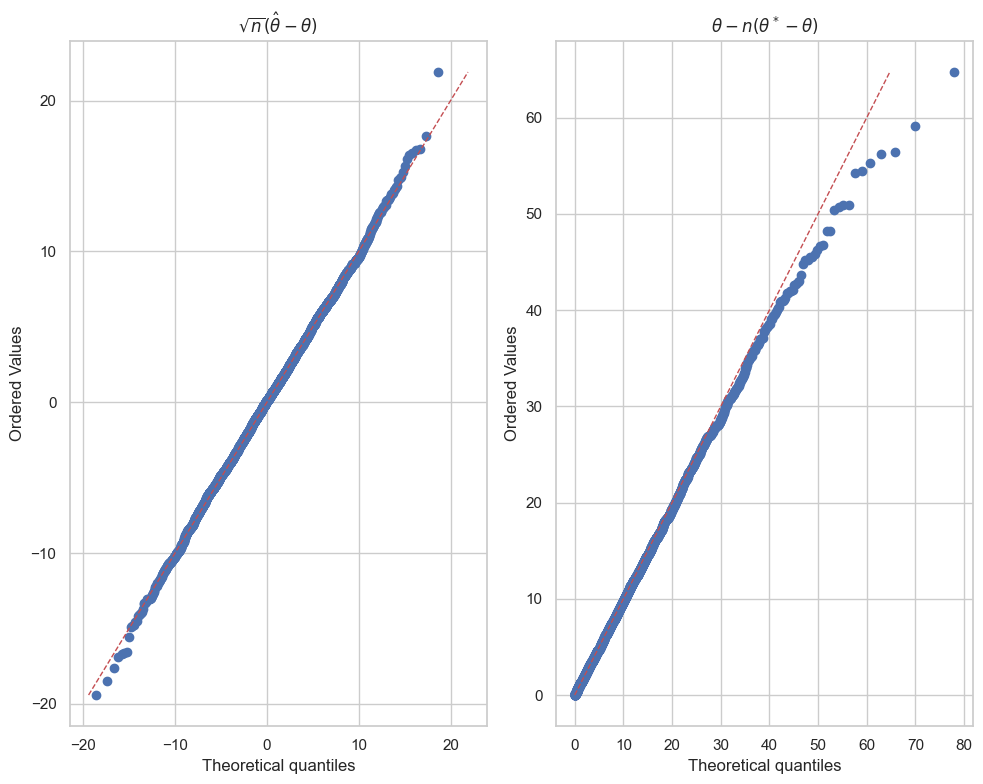

In [658]:
N = 10_000
Z1 = np.sqrt(N) * (theta_hat - THETA)
Z2 =  THETA- N * (theta_star - THETA)
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
probplot(Z1, dist=sps.norm(scale = THETA / np.sqrt(3)), fit=False, plot=axes[0])
lo1, hi1 = Z1.min(), Z1.max()
axes[0].plot([lo1, hi1], [lo1, hi1], 'r--', lw=1)
axes[0].set_title(r'$\sqrt{n}(\hat\theta-\theta)$')
probplot(Z2, dist=sps.expon(scale = THETA), fit=False, plot=axes[1])
lo2, hi2 = 0.0, Z2.max()
axes[1].plot([lo2, hi2], [lo2, hi2], 'r--', lw=1)
axes[1].set_title(r'$\theta-n(\theta^*-\theta)$')

plt.tight_layout()
plt.show()

Ура, все сошлось с теорией

5. Бонусная часть (+5 баллов): Если Вы нашли семейство распределений, которое по QQ-plot соответствует выборке, то докажите строго, что $n(\theta^* - \theta)$ сходится к нему. Заметьте, что это утверждение от асимптотической нормальности отличается только заменой $\sqrt{n}$ на $n$. Такие оценки называются **сверхнормальными**. В конце доказательства поясните:

- как множитель, зависящий от $n$, связан с скоростью сходимости оценки на практике?
- лучше ли сверхномальная оценка, чем нормальная оценка?

доказал сходимость я выше.
1)множитель по сути говорит нам об допустимой ошибке и сходится гораздо быстрее при n($O_p(1/n)$). Полагаю у нее и MSE меньше будет - то есть она строго лучше
2) да строго лучше, по первому пункту

**Доказательство:**

6. Сделайте вывод о том, какая оценка лучше на практике. Зачем может быть важно знать точную скорость сходимости (функцию от $n$) и предельное распределение?

Ну значительно лучше будет $\theta^*$ по причинам предыдущего пункта. К тому же получается что мы умеем оценивать $\theta^*$ через $\theta$ => знаем все параметры. Вероятно мы можем писать вместо $F_n$ просто $F$ и строить доверительные интервалы и прочие вещи

**Не забудьте перезапустить с нуля весь ноутбук перед отправкой! Habe Mut, dich deines eigenen Verstandes zu bedienen!**
